# Calculadora de potenciales y campo en el sistema acelerador

El siguiente programa permite el cálculo numérico del potencial en todo el bulbo de vacío del experimento $e/m$ a partir de una disposición dada de cátodo y anodo.

In [2]:
import scipy.constants as ctes
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Ingresamso algunos parámetros sobre el espacio sobre el que se estará trabajando. Pretende ser un espacio bidimensional de tamaño 'field_size' y resolución 'spatial_resolution', con el origen situado en 'origin_position'. Tener en cuenta que los electrones saldrán del origen y que la resolución espacial afectará mucho el tiempo de cálculo de las matrices 'absortion_mask' (booleana), 'potential' (escalar) y 'E' (vectorial 2d).

In [3]:
field_size = 0.2, 0.2 # m, m
origin_position = 0.10, 0.02 # m, m 
spatial_resolution = 0.001# m

In [4]:
potential = pd.DataFrame(np.empty((int(field_size[0]//spatial_resolution),int(field_size[1]//spatial_resolution))),
             columns = np.linspace(-origin_position[0],-origin_position[0]+field_size[0], int(field_size[0]//spatial_resolution)),
             index = np.flip(np.linspace(-origin_position[1],-origin_position[1]+field_size[1], int(field_size[1]//spatial_resolution))))

absortion_mask = pd.DataFrame(np.empty((int(field_size[0]//spatial_resolution),int(field_size[1]//spatial_resolution))).astype(bool),
             columns = np.linspace(-origin_position[0],-origin_position[0]+field_size[0], int(field_size[0]//spatial_resolution)),
             index = np.flip(np.linspace(-origin_position[1],-origin_position[1]+field_size[1], int(field_size[1]//spatial_resolution))))

absortion_mask.iloc[0,:] = True
absortion_mask.iloc[-1,:] = True
absortion_mask.iloc[:,0] = True
absortion_mask.iloc[:,-1] = True

In [5]:
Cathode_size = 0.01, 0.05 # m, m
Cathode_potential = -50 # V

Anode_distance = 0.05 # m
Anode_size = 0.01, 0.05 # m, m
Anode_windows_height = 0.02 # m
Anode_potential = +250 # V

In [ ]:
def set_potential_region(df, x_range, y_range, value):
  """
  Sobrescribe una región de un DataFrame con un valor dado.

  Args:
    df (pd.DataFrame): El DataFrame a modificar.
    x_range (list or tuple): Rango de valores en el eje x (columnas).
    y_range (list or tuple): Rango de valores en el eje y (filas).
    value (int or float): El valor para asignar a la región.
  """
  # Encontrar los índices de inicio y fin en el eje y (filas)
  y_start_index = df.index.get_indexer([y_range[0]], method='nearest')[0]
  y_end_index = df.index.get_indexer([y_range[1]], method='nearest')[0]

  # Encontrar los índices de inicio y fin en el eje x (columnas)
  x_start_index = df.columns.get_indexer([x_range[0]], method='nearest')[0]
  x_end_index = df.columns.get_indexer([x_range[1]], method='nearest')[0]

  # Asegurar que el rango de índices de fila sea ascendente
  if y_start_index > y_end_index:
    y_start_index, y_end_index = y_end_index, y_start_index
  
  # Asignar el valor a la región seleccionada usando iloc
  df.iloc[y_start_index:y_end_index + 1, x_start_index:x_end_index + 1] = value

In [7]:
absortion_mask.loc[-0.01:0.01,-0.01:0.01] = True

In [10]:
absortion_mask.loc[-0.01:,-0.01:0.01]

,-0.009548,-0.008543,-0.007538,-0.006533,-0.005528,-0.004523,-0.003518,-0.002513,-0.001508,-0.000503,0.000503,0.001508,0.002513,0.003518,0.004523,0.005528,0.006533,0.007538,0.008543,0.009548
-0.010955,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.011960,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.012965,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.013970,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.014975,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.015980,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.016985,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.017990,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.018995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
-0.020000,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [ ]:
potential.loc[-Cathode_size[0]/2:Cathode_size[0]/2,-Cathode_size[1]:0] = Cathode_potential
absortion_mask.loc[-Cathode_size[0]/2:Cathode_size[0]/2,-Cathode_size[1]:0] = True

potential[Anode_windows_height/2:Anode_size[1]/2,Anode_distance-Anode_size[0]:Anode_distance+Anode_size[0]] = Anode_potential
potential.loc[-Anode_size[1]/2:-Anode_windows_height/2,Anode_distance-Anode_size[0]:Anode_distance+Anode_size[0]] = Anode_potential

absortion_mask.loc[Anode_windows_height/2:Anode_size[1]/2,Anode_distance-Anode_size[0]:Anode_distance+Anode_size[0]] = True
absortion_mask.loc[-Anode_size[1]/2:-Anode_windows_height/2,Anode_distance-Anode_size[0]:Anode_distance+Anode_size[0]] = True

InvalidIndexError: (slice(0.01, 0.025, None), slice(0.04, 0.060000000000000005, None))

<Axes: >

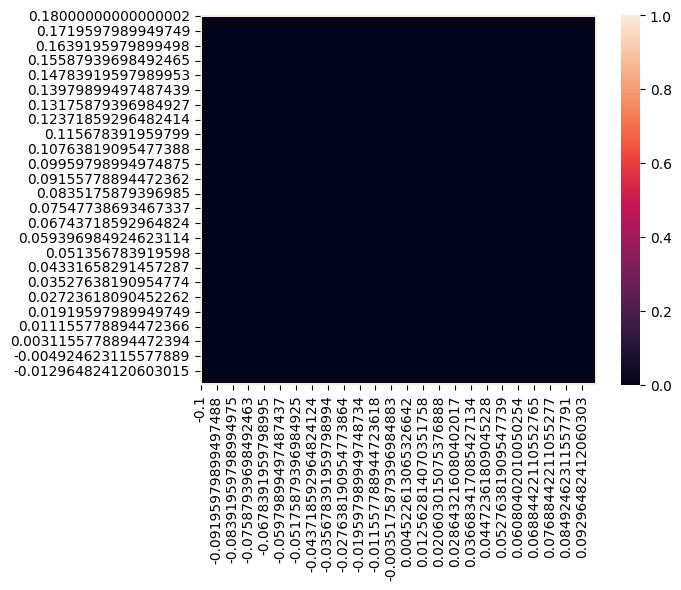

In [ ]:
sns.heatmap(absortion_mask, annot= False)

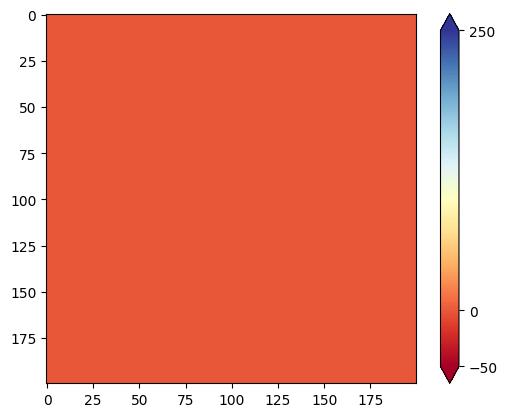

In [ ]:
fig, ax = plt.subplots()
cax = ax.imshow(potential, cmap ="RdYlBu", vmin = -50, vmax = 250)
#plt.ylim(-0.02,0.02)
#plt.xlim(-0.06,0.06)
cbar = fig.colorbar(cax,
                    ticks=[-50, 0, 250],
                    extend='both'
                    )
labels = cbar.ax.get_yticklabels()